# Analisis Sentimen dengan SVM

Notebook ini menggunakan data hasil labeling IndoBERTweet yang sudah tersedia, sehingga **tidak ada proses labeling ulang** dan **tidak ada visualisasi distribusi sentimen**.  
Kolom yang digunakan hanya:

- `text` sebagai teks asli
- `label_sentimen` sebagai label sentimen

Kolom `text_preprocessing_awal` / `text_processing_awal` tidak digunakan.

Tahap preprocessing lanjutan menggunakan:

- **Kamus Alay** untuk normalisasi kata tidak baku/slang
- **Sastrawi** untuk stopword removal
- **Sastrawi** untuk stemming


In [ ]:
# Install library yang dibutuhkan
!pip -q install Sastrawi wordcloud

In [ ]:
# ==========================
# 1. Import Library
# ==========================
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from wordcloud import WordCloud

In [ ]:
# ==========================
# 2. Load Data
# ==========================
file_path = "02_hasil_labeling_indobertweet.csv"

df = pd.read_csv(file_path)

# Gunakan hanya kolom text dan label_sentimen
df = df[["text", "label_sentimen"]].copy()

# Hapus data kosong
df = df.dropna(subset=["text", "label_sentimen"]).reset_index(drop=True)

# Pastikan tipe data string dan label konsisten
df["text"] = df["text"].astype(str)
df["label_sentimen"] = df["label_sentimen"].astype(str).str.lower().str.strip()

print("Jumlah data:", len(df))
print("\nKolom yang digunakan:")
print(df.columns.tolist())

print("\nDistribusi label:")
print(df["label_sentimen"].value_counts())

df.head()

Jumlah data: 6902

Kolom yang digunakan:
['text', 'label_sentimen']

Distribusi label:
label_sentimen
negatif    4402
netral     2005
positif     495
Name: count, dtype: int64


,text,label_sentimen
0,Media Asing Sorot Prabowo Ganti Kepala BGN Seb...,netral
1,@txtdrimedia Berikut ini perkiraan penyebab ke...,negatif
2,@TeddGus Santai aja @TeddGus .. ngapain lw res...,negatif
3,@Ogaman888 Kalo orang pinter dan ga rakus ide ...,netral
4,@mfsa118 kata pemilihnya karna beliau backgrou...,negatif


In [ ]:
# ==========================
# 3. Cleaning
# ==========================
def cleaning_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+|https\S+", " ", text)  # hapus URL
    text = re.sub(r"@\w+", " ", text)                       # hapus mention
    text = re.sub(r"#", "", text)                           # hapus simbol hashtag
    text = re.sub(r"\brt\b", " ", text, flags=re.IGNORECASE) # hapus retweet marker
    text = re.sub(r"[^a-zA-Z\s]", " ", text)               # hapus angka dan karakter selain huruf
    text = re.sub(r"\s+", " ", text).strip()               # hapus spasi berlebih
    return text

df["text_clean"] = df["text"].apply(cleaning_text)

# Menampilkan jumlah data setelah cleaning
print("Jumlah data setelah cleaning:", len(df))

df[["text", "text_clean", "label_sentimen"]].head()

Jumlah data setelah cleaning: 6902


,text,text_clean,label_sentimen
0,Media Asing Sorot Prabowo Ganti Kepala BGN Seb...,Media Asing Sorot Prabowo Ganti Kepala BGN Seb...,netral
1,@txtdrimedia Berikut ini perkiraan penyebab ke...,Berikut ini perkiraan penyebab kematian sapi m...,negatif
2,@TeddGus Santai aja @TeddGus .. ngapain lw res...,Santai aja ngapain lw respon netijen yang bila...,negatif
3,@Ogaman888 Kalo orang pinter dan ga rakus ide ...,Kalo orang pinter dan ga rakus ide itu masih t...,netral
4,@mfsa118 kata pemilihnya karna beliau backgrou...,kata pemilihnya karna beliau background milite...,negatif


In [ ]:
# ==========================
# 4. Case Folding
# ==========================
df["text_casefolding"] = df["text_clean"].str.lower()

df[["text_clean", "text_casefolding"]].head()

,text_clean,text_casefolding
0,Media Asing Sorot Prabowo Ganti Kepala BGN Seb...,media asing sorot prabowo ganti kepala bgn seb...
1,Berikut ini perkiraan penyebab kematian sapi m...,berikut ini perkiraan penyebab kematian sapi m...
2,Santai aja ngapain lw respon netijen yang bila...,santai aja ngapain lw respon netijen yang bila...
3,Kalo orang pinter dan ga rakus ide itu masih t...,kalo orang pinter dan ga rakus ide itu masih t...
4,kata pemilihnya karna beliau background milite...,kata pemilihnya karna beliau background milite...


In [ ]:
# ==========================
# 5. Normalisasi Kata Tidak Baku dengan Kamus Alay
# ==========================
# Repository yang digunakan:
# https://github.com/nasalsabila/kamus-alay
# File kamus akan otomatis dibaca dari file lokal jika tersedia.
# Jika belum tersedia, notebook akan mencoba mengunduh dari GitHub.

KAMUS_ALAY_LOCAL = "colloquial-indonesian-lexicon.csv"
KAMUS_ALAY_URL = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"


def read_csv_flexible(source):
    """Membaca CSV dengan beberapa encoding agar lebih aman."""
    for enc in ["utf-8", "latin-1", "ISO-8859-1"]:
        try:
            return pd.read_csv(source, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(source)


def load_kamus_alay():
    """Memuat Kamus Alay dan mengubahnya menjadi dictionary slang -> formal."""
    if os.path.exists(KAMUS_ALAY_LOCAL):
        kamus = read_csv_flexible(KAMUS_ALAY_LOCAL)
        print(f"Kamus Alay dibaca dari file lokal: {KAMUS_ALAY_LOCAL}")
    else:
        try:
            kamus = read_csv_flexible(KAMUS_ALAY_URL)
            kamus.to_csv(KAMUS_ALAY_LOCAL, index=False)
            print("Kamus Alay berhasil diunduh dari GitHub.")
        except Exception as e:
            raise FileNotFoundError(
                "Kamus Alay belum tersedia dan gagal diunduh. "
                "Silakan upload file 'colloquial-indonesian-lexicon.csv' ke folder kerja Colab, "
                "lalu jalankan ulang cell ini."
            ) from e

    # Samakan nama kolom agar fleksibel terhadap format file kamus
    kamus.columns = [str(col).lower().strip() for col in kamus.columns]

    if "slang" in kamus.columns and "formal" in kamus.columns:
        kamus = kamus[["slang", "formal"]].copy()
    else:
        # Jika format berbeda, gunakan dua kolom pertama sebagai slang dan formal
        kamus = kamus.iloc[:, :2].copy()
        kamus.columns = ["slang", "formal"]

    kamus = kamus.dropna(subset=["slang", "formal"])
    kamus["slang"] = kamus["slang"].astype(str).str.lower().str.strip()
    kamus["formal"] = kamus["formal"].astype(str).str.lower().str.strip()
    kamus = kamus.drop_duplicates(subset="slang", keep="first")

    return dict(zip(kamus["slang"], kamus["formal"]))


normalisasi_dict = load_kamus_alay()

# Kata yang dikecualikan dari proses normalisasi
# "mbg" dipertahankan karena merupakan objek penelitian
# "g" dikecualikan karena rawan menjadi noise jika otomatis diubah menjadi "tidak"
pengecualian_normalisasi = {"mbg","ngapain"}

# Hapus kata pengecualian dari kamus jika ternyata ada di Kamus Alay
# agar tidak berubah menjadi kata lain
for kata in pengecualian_normalisasi:
    normalisasi_dict.pop(kata, None)

# Tambahan normalisasi khusus untuk data penelitian
# Bagian ini memaksa variasi kata negasi menjadi bentuk baku "tidak"
tambahan_normalisasi = {
    # variasi negasi
    "tdk": "tidak",
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "enggak": "tidak",
    "engga": "tidak",
    "ngak": "tidak",
    "ngk": "tidak",
    "nggk": "tidak",
    "ngg": "tidak",
    "gaa": "tidak",
    "nga": "tidak",
    "gag": "tidak",
    "g": "tidak",

    # bentuk gabungan yang sering muncul di media sosial
    "gamau": "tidak mau",
    "gmau": "tidak mau",
    "gabisa": "tidak bisa",
    "gbs": "tidak bisa",
    "gada": "tidak ada",
    "gaada": "tidak ada",
    "gda": "tidak ada",
    "gatau": "tidak tahu",
    "gtau": "tidak tahu",
    "gajelas": "tidak jelas",
    "gaje": "tidak jelas",
    "gausah": "tidak usah",
    "gausa": "tidak usah",
    "gakusah": "tidak usah",
    "gpp": "tidak apa-apa",
    "gakpapa": "tidak apa-apa",
    "gabakal": "tidak bakal",
    "gapunya": "tidak punya",
    "gapernah": "tidak pernah",
    "gasalah": "tidak salah",

    # singkatan umum
    "yg": "yang",
    "dgn": "dengan",
    "utk": "untuk",
    "krn": "karena",
    "karna": "karena"
}

# Gunakan update agar aturan tambahan menimpa isi Kamus Alay
# Contoh: jika Kamus Alay mengubah "gak" menjadi "enggak",
# maka bagian ini akan menggantinya menjadi "tidak"
normalisasi_dict.update(tambahan_normalisasi)


def normalisasi_text(text):
    tokens = str(text).split()
    normalized_tokens = [
        token if token in pengecualian_normalisasi else normalisasi_dict.get(token, token)
        for token in tokens
    ]
    return " ".join(normalized_tokens)


df["text_normalisasi"] = df["text_casefolding"].apply(normalisasi_text)

print("Jumlah kata dalam kamus normalisasi:", len(normalisasi_dict))
df[["text_casefolding", "text_normalisasi"]].head()

Kamus Alay dibaca dari file lokal: colloquial-indonesian-lexicon.csv
Jumlah kata dalam kamus normalisasi: 4329


,text_casefolding,text_normalisasi
0,media asing sorot prabowo ganti kepala bgn seb...,media asing sorot prabowo ganti kepala bgn seb...
1,berikut ini perkiraan penyebab kematian sapi m...,berikut ini perkiraan penyebab kematian sapi m...
2,santai aja ngapain lw respon netijen yang bila...,santai saja ngapain lu respon netijen yang bil...
3,kalo orang pinter dan ga rakus ide itu masih t...,kalo orang pintar dan tidak rakus ide itu masi...
4,kata pemilihnya karna beliau background milite...,kata pemilihnya karena beliau background milit...


In [ ]:
# ==========================
# 6. Tokenizing
# ==========================
df["text_tokenized"] = df["text_normalisasi"].apply(lambda x: x.split())

df[["text_normalisasi", "text_tokenized"]].head()

,text_normalisasi,text_tokenized
0,media asing sorot prabowo ganti kepala bgn seb...,"[media, asing, sorot, prabowo, ganti, kepala, ..."
1,berikut ini perkiraan penyebab kematian sapi m...,"[berikut, ini, perkiraan, penyebab, kematian, ..."
2,santai saja ngapain lu respon netijen yang bil...,"[santai, saja, ngapain, lu, respon, netijen, y..."
3,kalo orang pintar dan tidak rakus ide itu masi...,"[kalo, orang, pintar, dan, tidak, rakus, ide, ..."
4,kata pemilihnya karena beliau background milit...,"[kata, pemilihnya, karena, beliau, background,..."


In [ ]:
# ==========================
# 7. Stopword Removal dengan Sastrawi
# ==========================
factory_stopword = StopWordRemoverFactory()
stop_words = set(factory_stopword.get_stop_words())

# Kata negasi dipertahankan karena penting dalam analisis sentimen.
# Contoh: "tidak baik" berbeda makna dengan "baik".
kata_negasi = {
    "tidak", "bukan", "belum", "jangan",
    "ga", "gak", "nggak", "ngga", "tdk"
}
stop_words = stop_words - kata_negasi

# Stopword tambahan sesuai konteks data Twitter/X.
custom_stopwords = {
    "rt", "http", "https", "url", "user"
}
stop_words = stop_words.union(custom_stopwords)


def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words and len(word) > 1]


df["text_stopword"] = df["text_tokenized"].apply(remove_stopwords)

print("Jumlah stopword Sastrawi yang digunakan:", len(stop_words))
df[["text_tokenized", "text_stopword"]].head()

Jumlah stopword Sastrawi yang digunakan: 125


,text_tokenized,text_stopword
0,"[media, asing, sorot, prabowo, ganti, kepala, ...","[media, asing, sorot, prabowo, ganti, kepala, ..."
1,"[berikut, ini, perkiraan, penyebab, kematian, ...","[berikut, perkiraan, penyebab, kematian, sapi,..."
2,"[santai, saja, ngapain, lu, respon, netijen, y...","[santai, ngapain, lu, respon, netijen, bilang,..."
3,"[kalo, orang, pintar, dan, tidak, rakus, ide, ...","[kalo, orang, pintar, tidak, rakus, ide, tetap..."
4,"[kata, pemilihnya, karena, beliau, background,...","[kata, pemilihnya, beliau, background, militer..."


In [ ]:
# ==========================
# 8. Stemming
# ==========================
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

def stemming_tokens(tokens):
    text = " ".join(tokens)
    return stemmer.stem(text)

df["text_stemmed"] = df["text_stopword"].apply(stemming_tokens)

df[["text_stopword", "text_stemmed"]].head()

,text_stopword,text_stemmed
0,"[media, asing, sorot, prabowo, ganti, kepala, ...",media asing sorot prabowo ganti kepala bgn seb...
1,"[berikut, perkiraan, penyebab, kematian, sapi,...",ikut kira sebab mati sapi ahli keblinger lingk...
2,"[santai, ngapain, lu, respon, netijen, bilang,...",santai ngapain lu respon netijen bilang prabow...
3,"[kalo, orang, pintar, tidak, rakus, ide, tetap...",kalo orang pintar tidak rakus ide tetap realis...
4,"[kata, pemilihnya, beliau, background, militer...",kata pilih beliau background militer jadi bagu...


In [ ]:
# ==========================
# 9. Simpan Data Hasil Preprocessing
# ==========================
df_final = df[["text_stemmed", "label_sentimen"]].copy()
df_final = df_final.rename(columns={"text_stemmed": "text_processed"})

# Hapus data kosong setelah preprocessing
df_final = df_final.dropna(subset=["text_processed", "label_sentimen"])
df_final = df_final[df_final["text_processed"].str.strip() != ""].reset_index(drop=True)

df_final.to_csv("03_hasil_preprocessing_lanjutan.csv", index=False)

print("Jumlah data akhir:", len(df_final))
df_final.head()

Jumlah data akhir: 6627


,text_processed,label_sentimen
0,media asing sorot prabowo ganti kepala bgn seb...,netral
1,ikut kira sebab mati sapi ahli keblinger lingk...,negatif
2,santai ngapain lu respon netijen bilang prabow...,negatif
3,kalo orang pintar tidak rakus ide tetap realis...,netral
4,kata pilih beliau background militer jadi bagu...,negatif


In [ ]:
# ==========================
# 10. TF-IDF dan Split Data 70:30
# ==========================
X = df_final["text_processed"]
y = df_final["label_sentimen"]

# Split data 70% latih dan 30% uji
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# TF-IDF dibuat setelah split agar tidak terjadi data leakage
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print("Jumlah data latih:", X_train_tfidf.shape[0])
print("Jumlah data uji:", X_test_tfidf.shape[0])
print("Jumlah fitur TF-IDF:", X_train_tfidf.shape[1])

Jumlah data latih: 4638
Jumlah data uji: 1989
Jumlah fitur TF-IDF: 7241


In [ ]:
# ==========================
# 11. Klasifikasi Menggunakan SVM
# ==========================
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_pred = svm_model.predict(X_test_tfidf)

print("Model SVM selesai dilatih.")
# ==========================
# Simpan Hasil Prediksi SVM
# ==========================
hasil_prediksi = pd.DataFrame({
    "teks": X_test_text.reset_index(drop=True),
    "label_asli": y_test.reset_index(drop=True),
    "label_prediksi": pd.Series(y_pred)
})

hasil_prediksi["status"] = (
    hasil_prediksi["label_asli"] == hasil_prediksi["label_prediksi"]
).map({True: "Benar", False: "Salah"})

hasil_prediksi.to_csv(
    "05_hasil_prediksi_svm.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Hasil prediksi berhasil disimpan.")
hasil_prediksi.head()

Model SVM selesai dilatih.
Hasil prediksi berhasil disimpan.


,teks,label_asli,label_prediksi,status
0,omong harga okky jelly drink perak bikin gue a...,negatif,negatif,Benar
1,rakyat cuma statistik tidak punya value apa bo...,negatif,negatif,Benar
2,sering setor gila,positif,negatif,Salah
3,coba racun mati harus tidak masalah sekian rat...,negatif,negatif,Benar
4,wakil meng iya,negatif,netral,Salah


In [ ]:
# ==========================
# 12. Evaluasi Model
# ==========================
label_order = [label for label in ["negatif", "netral", "positif"] if label in sorted(y.unique())]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, labels=label_order, zero_division=0))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("=== Evaluasi Total ===")
print(f"Akurasi  : {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall   : {recall:.2%}")
print(f"F1-Score : {f1:.2%}")

report = classification_report(
    y_test,
    y_pred,
    labels=label_order,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("04_evaluasi_svm.csv", index=True)

report_df

=== Classification Report ===
              precision    recall  f1-score   support

     negatif       0.79      0.90      0.84      1305
      netral       0.67      0.57      0.62       538
     positif       0.73      0.26      0.38       146

    accuracy                           0.76      1989
   macro avg       0.73      0.58      0.62      1989
weighted avg       0.76      0.76      0.75      1989

=== Evaluasi Total ===
Akurasi  : 76.42%
Precision: 75.64%
Recall   : 76.42%
F1-Score : 74.88%


,precision,recall,f1-score,support
negatif,0.793243,0.899617,0.843088,1305.000000
netral,0.673961,0.572491,0.619095,538.000000
positif,0.730769,0.260274,0.383838,146.000000
accuracy,0.764203,0.764203,0.764203,0.764203
macro avg,0.732658,0.577461,0.615341,1989.000000
weighted avg,0.756393,0.764203,0.748790,1989.000000


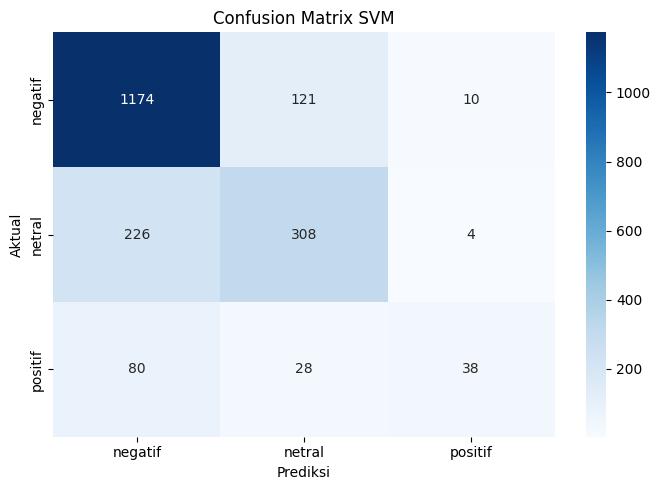

In [ ]:
# ==========================
# 13. Confusion Matrix
# ==========================
cm = confusion_matrix(y_test, y_pred, labels=label_order)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order
)
plt.title("Confusion Matrix SVM")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

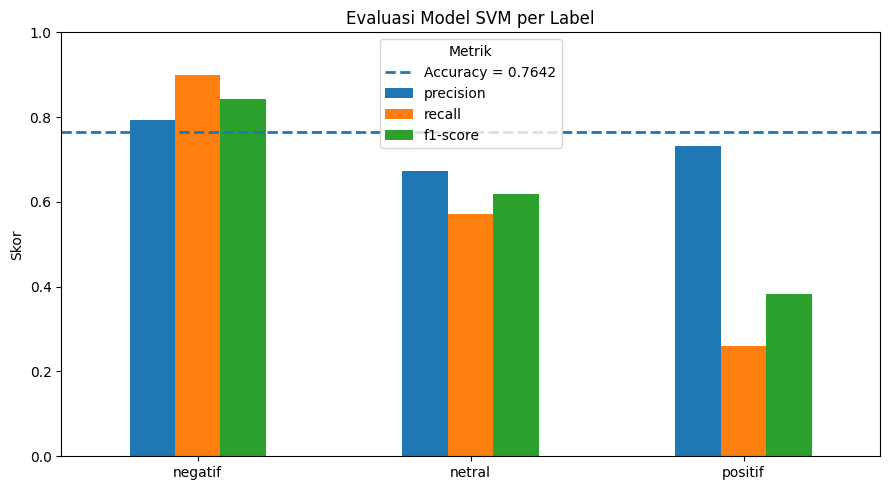

In [ ]:
# ==========================
# 14. Visualisasi Evaluasi Model per Label + Akurasi
# ==========================

from sklearn.metrics import accuracy_score

# Ambil precision, recall, dan f1-score per label
metrics_df = report_df.loc[label_order, ["precision", "recall", "f1-score"]]

# Hitung akurasi model
accuracy = accuracy_score(y_test, y_pred)

# Plot precision, recall, dan f1-score per label
ax = metrics_df.plot(kind="bar", figsize=(9, 5))

# Tambahkan garis akurasi
plt.axhline(
    y=accuracy,
    linestyle="--",
    linewidth=2,
    label=f"Accuracy = {accuracy:.4f}"
)

plt.title("Evaluasi Model SVM per Label")
plt.ylabel("Skor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrik")
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

# Document Frequency
doc_freq = Counter()

for text in X_train_text:
    words = set(str(text).split())
    doc_freq.update(words)

# Total Frequency
total_freq = Counter()

for text in X_train_text:
    total_freq.update(str(text).split())

# Frequency per kelas
positive_freq = Counter()
negative_freq = Counter()
neutral_freq = Counter()

for text, label in zip(X_train_text, y_train):

    words = str(text).split()

    if label.lower() == "positif":
        positive_freq.update(words)

    elif label.lower() == "negatif":
        negative_freq.update(words)

    elif label.lower() == "netral":
        neutral_freq.update(words)

In [ ]:
# ==========================
# Top 10 Kata Berdasarkan TF-IDF
# ==========================

feature_names = vectorizer.get_feature_names_out()
tfidf_means = X_train_tfidf.mean(axis=0).A1

top_idx = tfidf_means.argsort()[::-1][:10]
top_words = [feature_names[i] for i in top_idx]

rows = []

for i, word in enumerate(top_words, start=1):

    rows.append([
        i,
        word,
        doc_freq.get(word, 0),
        total_freq.get(word, 0),
        positive_freq.get(word, 0),
        negative_freq.get(word, 0),
        neutral_freq.get(word, 0),
        round(tfidf_means[top_idx[i-1]], 4)
    ])

tfidf_table = pd.DataFrame(
    rows,
    columns=[
        "Row No.",
        "Word",
        "In Documents",
        "Total",
        "In Class (Positif)",
        "In Class (Negatif)",
        "In Class (Netral)",
        "Mean TF-IDF"
    ]
)

display(tfidf_table)

,Row No.,Word,In Documents,Total,In Class (Positif),In Class (Negatif),In Class (Netral),Mean TF-IDF
0,1,mbg,1221,1508,107,907,494,0.0347
1,2,tidak,1092,1412,78,1119,215,0.0344
2,3,racun,895,1036,22,824,190,0.0313
3,4,makan,890,1069,62,502,505,0.0288
4,5,jadi,583,678,48,447,183,0.0204
5,6,gizi,588,757,47,178,532,0.0203
6,7,program,626,699,70,275,354,0.0196
7,8,gratis,542,578,36,151,391,0.0192
8,9,anak,412,565,31,426,108,0.0179
9,10,orang,333,383,13,302,68,0.0132


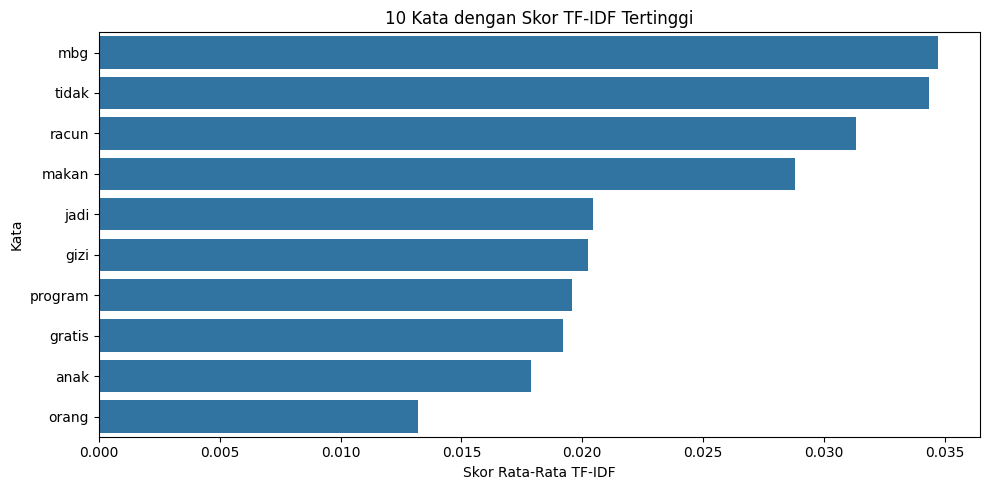

,word,tfidf_score
0,mbg,0.034721
1,tidak,0.034366
2,racun,0.031318
3,makan,0.028792
4,jadi,0.020449
5,gizi,0.020258
6,program,0.019588
7,gratis,0.019223
8,anak,0.017864
9,orang,0.013209


In [ ]:
# ==========================
# 15. Visualisasi Kata dengan Skor TF-IDF Tertinggi
# ==========================
feature_names = vectorizer.get_feature_names_out()
tfidf_means = X_train_tfidf.mean(axis=0).A1

top_indices = tfidf_means.argsort()[::-1][:10]
top_words_df = pd.DataFrame({
    "word": [feature_names[i] for i in top_indices],
    "tfidf_score": [tfidf_means[i] for i in top_indices]
})

plt.figure(figsize=(10, 5))
sns.barplot(x="tfidf_score", y="word", data=top_words_df)
plt.title("10 Kata dengan Skor TF-IDF Tertinggi")
plt.xlabel("Skor Rata-Rata TF-IDF")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

top_words_df

Jumlah data per sentimen:


,jumlah,count
0,negatif,4347
1,netral,1794
2,positif,486


WORD CLOUD DAN TOP 10 KATA SENTIMEN POSITIF


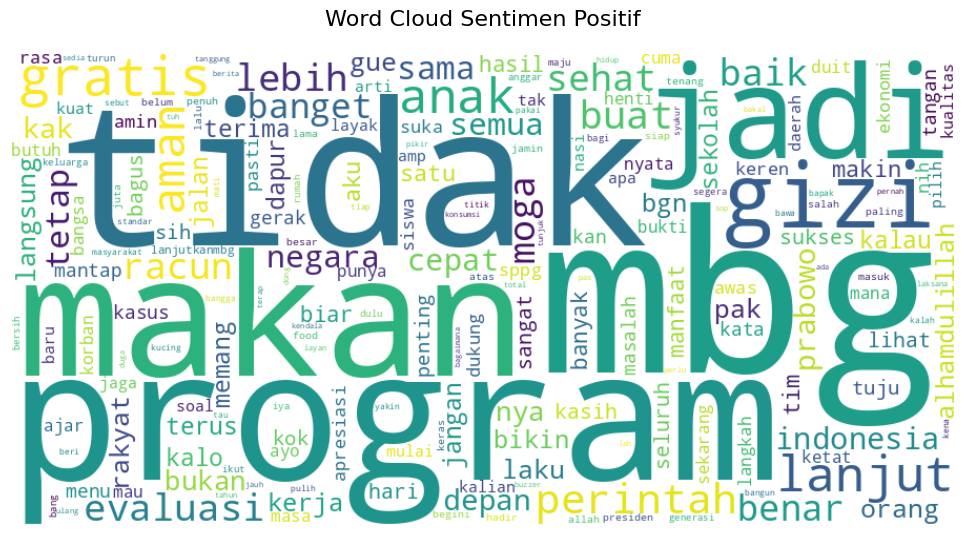

Top 10 Kata Sentimen Positif:


,Kata,Frekuensi
0,mbg,142
1,tidak,110
2,program,93
3,makan,91
4,jadi,68
5,gizi,64
6,gratis,53
7,lanjut,44
8,anak,42
9,aman,38


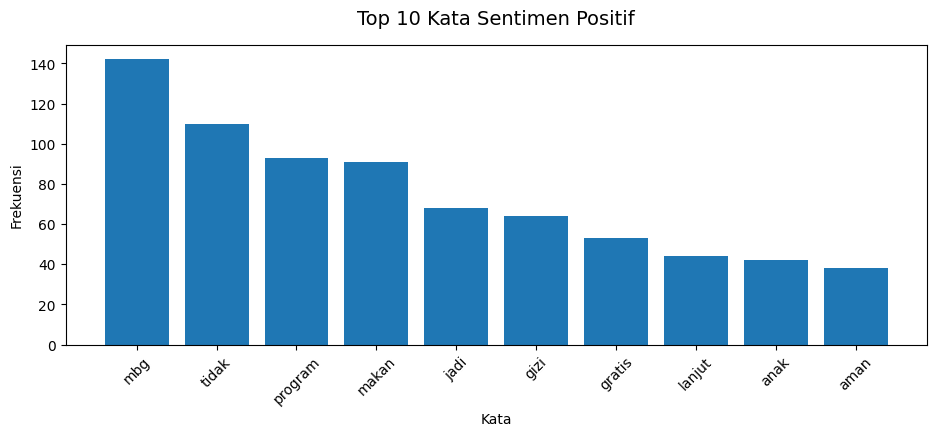

WORD CLOUD DAN TOP 10 KATA SENTIMEN NETRAL


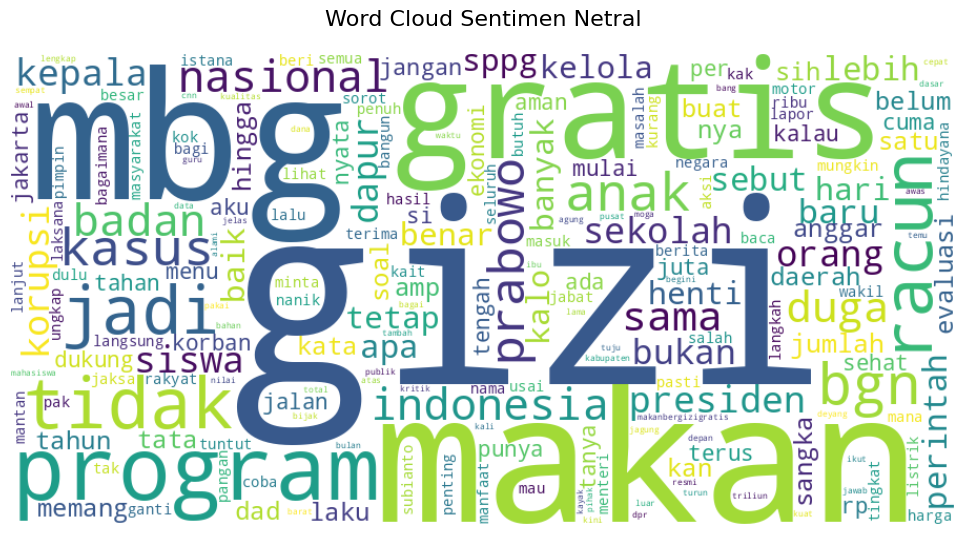

Top 10 Kata Sentimen Netral:


,Kata,Frekuensi
0,gizi,755
1,makan,725
2,mbg,695
3,gratis,559
4,program,497
5,tidak,304
6,racun,297
7,jadi,271
8,bgn,192
9,anak,161


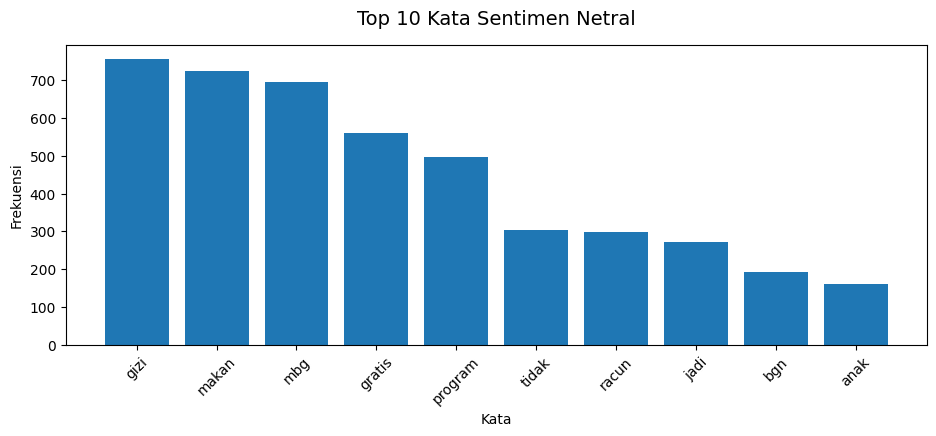

WORD CLOUD DAN TOP 10 KATA SENTIMEN NEGATIF


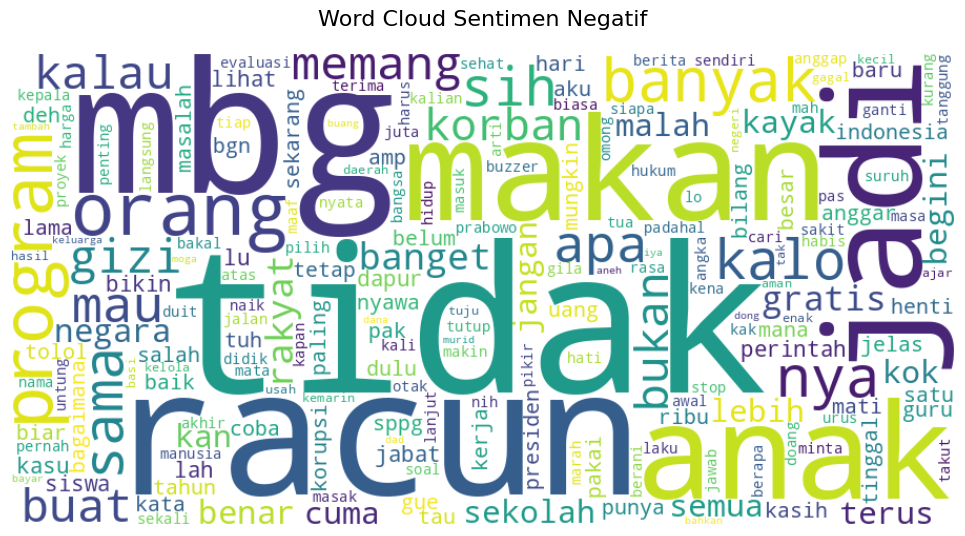

Top 10 Kata Sentimen Negatif:


,Kata,Frekuensi
0,tidak,1572
1,mbg,1259
2,racun,1176
3,makan,716
4,jadi,639
5,anak,617
6,orang,428
7,program,405
8,banyak,397
9,nya,367


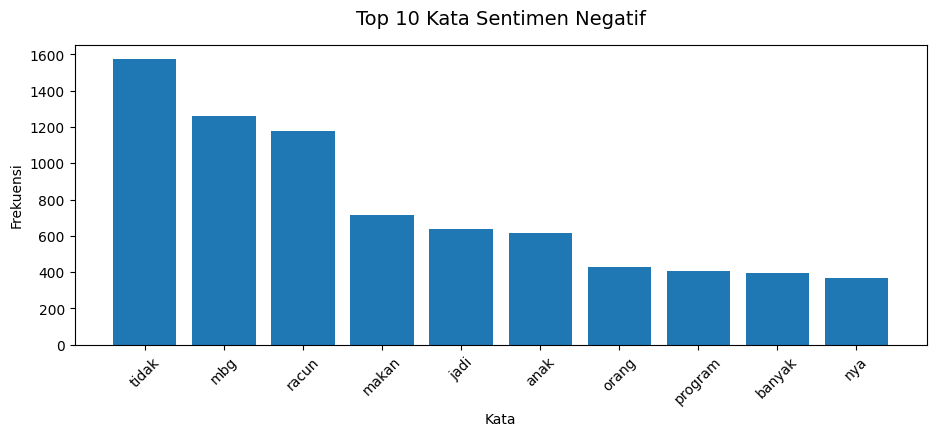

In [ ]:
# ==========================
# 16. Word Cloud dan Top 10 Kata per Sentimen
# ==========================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from IPython.display import display, HTML

# Pastikan label sentimen dalam format lowercase
df_final["label_sentimen"] = df_final["label_sentimen"].astype(str).str.lower().str.strip()

# Ubah label Inggris ke Indonesia jika diperlukan
label_mapping = {
    "positive": "positif",
    "neutral": "netral",
    "negative": "negatif"
}

df_final["label_sentimen"] = df_final["label_sentimen"].replace(label_mapping)

# Cek jumlah data per sentimen
print("Jumlah data per sentimen:")
display(df_final["label_sentimen"].value_counts().reset_index().rename(
    columns={"index": "label_sentimen", "label_sentimen": "jumlah"}
))

# Daftar sentimen
sentimen_list = ["positif", "netral", "negatif"]

for sentimen in sentimen_list:
    display(HTML("<hr style='margin: 40px 0;'>"))
    print(f"WORD CLOUD DAN TOP 10 KATA SENTIMEN {sentimen.upper()}")

    # Ambil teks berdasarkan sentimen
    teks_sentimen = " ".join(
        df_final[df_final["label_sentimen"] == sentimen]["text_processed"]
        .dropna()
        .astype(str)
    )

    if teks_sentimen.strip() == "":
        print(f"Tidak ada data untuk sentimen {sentimen}")
        continue

    # ==========================
    # Word Cloud per Sentimen
    # ==========================
    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white",
        collocations=False
    ).generate(teks_sentimen)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud Sentimen {sentimen.capitalize()}", fontsize=16, pad=20)
    plt.tight_layout(pad=3)
    plt.show()

    # Beri jarak antar visualisasi
    display(HTML("<br><br>"))

    # ==========================
    # Top 10 Kata per Sentimen
    # ==========================
    tokens = teks_sentimen.split()
    top_10 = Counter(tokens).most_common(10)

    top_10_df = pd.DataFrame(top_10, columns=["Kata", "Frekuensi"])

    print(f"Top 10 Kata Sentimen {sentimen.capitalize()}:")
    display(top_10_df)

    # ==========================
    # Grafik Top 10 Kata
    # ==========================
    plt.figure(figsize=(10, 5))
    plt.bar(top_10_df["Kata"], top_10_df["Frekuensi"])
    plt.title(f"Top 10 Kata Sentimen {sentimen.capitalize()}", fontsize=14, pad=15)
    plt.xlabel("Kata")
    plt.ylabel("Frekuensi")
    plt.xticks(rotation=45)
    plt.tight_layout(pad=3)
    plt.show()

## Ringkasan Alur Notebook

Alur analisis pada notebook ini adalah:

1. Load data hasil labeling IndoBERTweet
2. Menggunakan kolom `text` dan `label_sentimen`
3. Cleaning
4. Case folding
5. Normalisasi kata tidak baku menggunakan **Kamus Alay**
6. Tokenizing
7. Stopword removal menggunakan **Sastrawi**
8. Stemming menggunakan **Sastrawi**
9. TF-IDF
10. Split data 70:30
11. Klasifikasi SVM
12. Evaluasi model
13. Confusion matrix
14. Visualisasi TF-IDF
15. Word cloud
